In [110]:
# Import libraries
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve
from sklearn.decomposition import PCA
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

# Download NLTK stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vishnu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Load the dataset

In [111]:
# Load the dataset
file_path = "E:\\reviews.csv"
try:
    data = pd.read_csv(file_path)
    print("Data loaded successfully!")
except Exception as e:
    print(f"Error loading file: {e}")

# Ensure required columns are present
if 'text' not in data.columns or 'stars' not in data.columns:
    raise ValueError("The dataset must have 'text' and 'stars' columns!")

# Filter relevant columns
reviews = data[['text', 'stars']]

Data loaded successfully!


Categorize sentiment

In [132]:
# Categorize sentiment
def categorize_sentiment(stars):
    if stars >= 4:  # Positive sentiment
        return 'Positive'
    elif stars <= 2:  # Negative sentiment
        return 'Negative'
    else:  # Neutral sentiment
        return 'Neutral'

# Apply the function to create a new 'sentiment' column

#reviews.loc[:, 'sentiment'] = reviews['stars'].apply(categorize_sentiment)
reviews = reviews.copy()
reviews['sentiment'] = reviews['stars'].apply(categorize_sentiment)


# Display the first few rows to confirm
print("\nDataset with Sentiment Labels:")
print(reviews[['text', 'stars', 'sentiment']].head())

# Check the distribution of sentiment labels
print("\nSentiment Distribution:")
print(reviews['sentiment'].value_counts())


Dataset with Sentiment Labels:
                                                text  stars sentiment
0  If you decide to eat here, just be aware it is...      3   Neutral
1  I've taken a lot of spin classes over the year...      5  Positive
2  Family diner. Had the buffet. Eclectic assortm...      3   Neutral
3  Wow!  Yummy, different,  delicious.   Our favo...      5  Positive
4  Cute interior and owner (?) gave us tour of up...      4  Positive

Sentiment Distribution:
sentiment
Positive    343322
Negative    104089
Neutral      52589
Name: count, dtype: int64


 Clean text data

In [133]:
# Clean text data
def clean_text(text):
    # Handle negation patterns
    negation_patterns = [
        (r'\b(not|no|never|nothing|nowhere|none|nobody)\s+(\w+)', r'\1_\2'),
        (r'\b(cannot)\b', 'can_not'),
        (r'\b(ain\'t|aren\'t|don\'t|doesn\'t|didn\'t)\b', 'not'),
        (r'\b(isn\'t|wasn\'t|weren\'t|haven\'t|hasn\'t|hadn\'t)\b', 'not')
    ]
    
    for pattern, replacement in negation_patterns:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove stop words
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

stop_words = set(stopwords.words('english'))

#reviews.loc[:, 'cleaned_text'] = reviews['text'].apply(clean_text)

reviews = reviews.copy()  # Make a copy if it's a slice
reviews['cleaned_text'] = reviews['text'].apply(clean_text)

# Display the first few rows to confirm cleaning
print("\nCleaned Text Data:")
print(reviews[['text', 'cleaned_text']].head())


Cleaned Text Data:
                                                text  \
0  If you decide to eat here, just be aware it is...   
1  I've taken a lot of spin classes over the year...   
2  Family diner. Had the buffet. Eclectic assortm...   
3  Wow!  Yummy, different,  delicious.   Our favo...   
4  Cute interior and owner (?) gave us tour of up...   

                                        cleaned_text  
0  decide eat aware going take hours beginning en...  
1  ive taken lot spin classes years nothingcompar...  
2  family diner buffet eclectic assortment large ...  
3  wow yummy different delicious favorite lamb cu...  
4  cute interior owner gave us tour upcoming pati...  


# Split the data into training and testing sets

In [114]:
# Split the data into training and testing sets
X = reviews['cleaned_text']
y = reviews['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reduce dataset size for faster execution (optional)


# Display the size of the splits
print("\nData Split Completed:")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Data Split Completed:
Training set size: 400000
Testing set size: 100000


# Initialize CountVectorizer (Unigrams only)

In [115]:
# Initialize CountVectorizer (Unigrams only)
count_vectorizer = CountVectorizer(ngram_range=(1, 1))
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

# Print the shape to confirm the transformation
print("\nCount Vectorized Data (Unigrams) Shape:")
print(f"Training data shape: {X_train_count.shape}")
print(f"Testing data shape: {X_test_count.shape}")


Count Vectorized Data (Unigrams) Shape:
Training data shape: (400000, 241329)
Testing data shape: (100000, 241329)


# Initialize TF-IDF Vectorizer (Unigrams + Bigrams)

In [116]:
# Initialize TF-IDF Vectorizer (Unigrams + Bigrams)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Print the shape to confirm the transformation
print("\nTF-IDF Vectorized Data (Unigrams + Bigrams) Shape:")
print(f"Training data shape: {X_train_tfidf.shape}")
print(f"Testing data shape: {X_test_tfidf.shape}")


TF-IDF Vectorized Data (Unigrams + Bigrams) Shape:
Training data shape: (400000, 6432935)
Testing data shape: (100000, 6432935)


# One-Hot Encoding to training and testing data

In [117]:
# Apply One-Hot Encoding to training and testing data
def one_hot_encode(text_data):
    vectorizer = CountVectorizer(ngram_range=(1, 2), binary=True)
    X_one_hot = vectorizer.fit_transform(text_data)
    return X_one_hot, vectorizer

X_train_one_hot, one_hot_vectorizer = one_hot_encode(X_train)
X_test_one_hot = one_hot_vectorizer.transform(X_test)

# Print the shape of the One-Hot Encoded data
print("\nOne-Hot Encoded Data (Unigrams + Bigrams) Shape:")
print(f"Training data shape: {X_train_one_hot.shape}")
print(f"Testing data shape: {X_test_one_hot.shape}")


One-Hot Encoded Data (Unigrams + Bigrams) Shape:
Training data shape: (400000, 6432935)
Testing data shape: (100000, 6432935)


# Reduce dataset size for class seperability test on test and train data

In [126]:
# Reduce dataset size for faster execution (optional)
X_train1 = X_train[:2000]
y_train1 = y_train[:2000]
X_test1 = X_test[:500]
y_test1 = y_test[:500]
# Initialize CountVectorizer (Unigrams only)
count_vectorizer = CountVectorizer(ngram_range=(1, 1))
X_train_count = count_vectorizer.fit_transform(X_train1)
X_test_count = count_vectorizer.transform(X_test1)

# Print the shape to confirm the transformation
print("\nCount Vectorized Data (Unigrams) Shape:")
print(f"Training data shape: {X_train_count.shape}")
print(f"Testing data shape: {X_test_count.shape}")

# Apply One-Hot Encoding to training and testing data
def one_hot_encode(text_data):
    vectorizer = CountVectorizer(ngram_range=(1, 2), binary=True)
    X_one_hot = vectorizer.fit_transform(text_data)
    return X_one_hot, vectorizer

X_train_one_hot, one_hot_vectorizer = one_hot_encode(X_train1)
X_test_one_hot = one_hot_vectorizer.transform(X_test1)

# Print the shape of the One-Hot Encoded data
print("\nOne-Hot Encoded Data (Unigrams + Bigrams) Shape:")
print(f"Training data shape: {X_train_one_hot.shape}")
print(f"Testing data shape: {X_test_one_hot.shape}")

# Initialize TF-IDF Vectorizer (Unigrams + Bigrams)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train1)
X_test_tfidf = tfidf_vectorizer.transform(X_test1)

# Print the shape to confirm the transformation
print("\nTF-IDF Vectorized Data (Unigrams + Bigrams) Shape:")
print(f"Training data shape: {X_train_tfidf.shape}")
print(f"Testing data shape: {X_test_tfidf.shape}")


Count Vectorized Data (Unigrams) Shape:
Training data shape: (2000, 12998)
Testing data shape: (500, 12998)

One-Hot Encoded Data (Unigrams + Bigrams) Shape:
Training data shape: (2000, 96206)
Testing data shape: (500, 96206)

TF-IDF Vectorized Data (Unigrams + Bigrams) Shape:
Training data shape: (2000, 96206)
Testing data shape: (500, 96206)


# PCA and T-sine for class seperability test

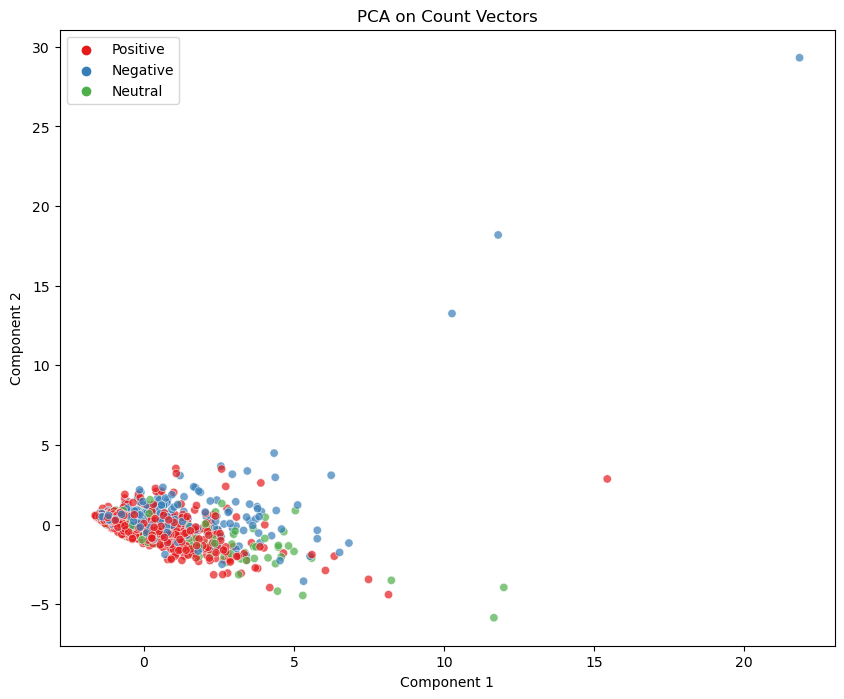

In [127]:
def plot_dimensionality_reduction(data, labels, method='PCA', title='Feature Visualization'):
    if method == 'PCA':
        reduced_data = PCA(n_components=2, random_state=42).fit_transform(data)
    elif method == 't-SNE':
        reduced_data = TSNE(n_components=2, random_state=42).fit_transform(data)
    else:
        raise ValueError("Unsupported method. Use 'PCA' or 't-SNE'.")

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=labels, palette='Set1', alpha=0.7)
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend()
    plt.show()

# Visualize class separability using PCA and t-SNE
plot_dimensionality_reduction(X_train_count.toarray(), y_train1, method='PCA', title='PCA on Count Vectors')


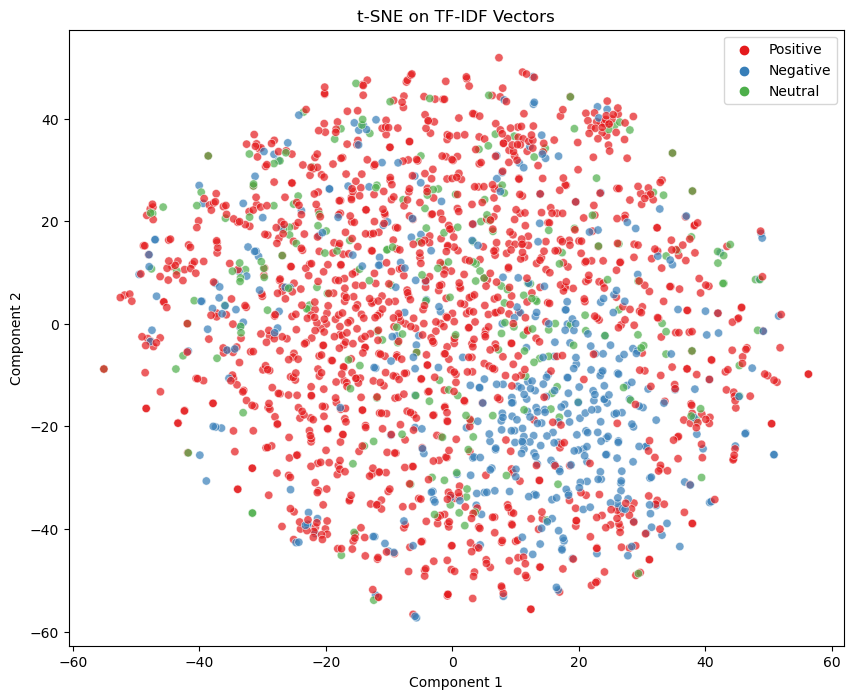

In [128]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
plot_dimensionality_reduction(X_train_tfidf.toarray(), y_train1, method='t-SNE', title='t-SNE on TF-IDF Vectors')

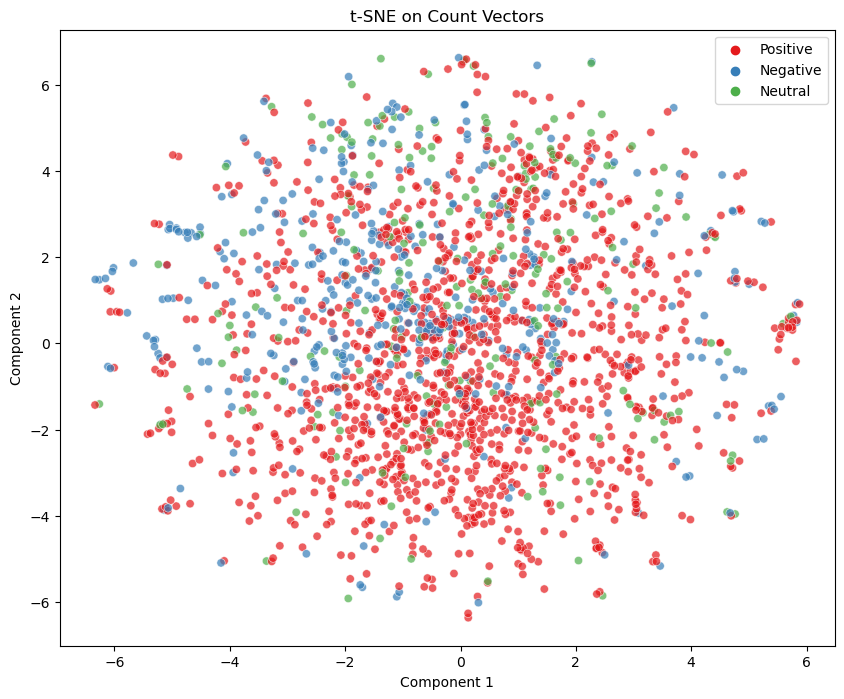

In [129]:
plot_dimensionality_reduction(X_train_count.toarray(), y_train1, method='t-SNE', title='t-SNE on Count Vectors')

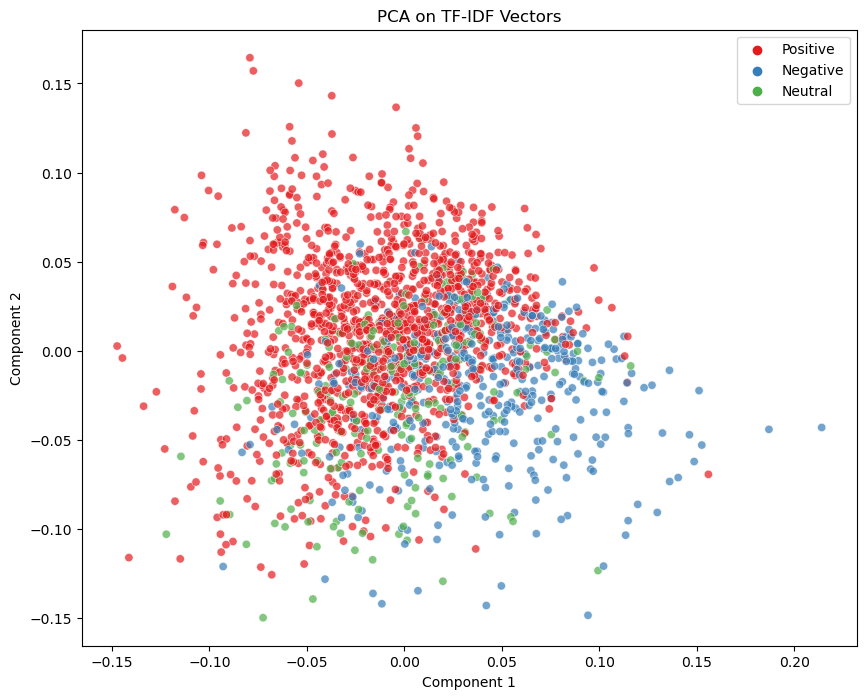

In [130]:
plot_dimensionality_reduction(X_train_tfidf.toarray(), y_train1, method='PCA', title='PCA on TF-IDF Vectors')